In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import json as js
import os
import glob

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['figure.dpi'] = 150  # ou 200

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Computer Modern par défaut
    "font.serif": ["Computer Modern"],  # Facultatif, plus explicite
    "axes.labelsize": 14,
    "font.size": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

In [4]:
data_dir = "DATA_Cluster/Disorder_parallel"
pattern = os.path.join(data_dir, "output_h_*_beta10.json")

data_dict = {}  # Dictionnaire pour stocker chaque contenu avec clé h_<valeur>

for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    
    # Extrait le nom comme "h_0.307" à partir de "output_h_0.307_beta10.json"
    name_part = filename.split("_beta10")[0].replace("output_", "")  # donne "h_0.307"
    
    with open(filepath, "r") as file:
        data_dict[name_part] = js.load(file)

print(data_dict.keys())

dict_keys(['h_2.293', 'h_3.024', 'h_3.448', 'h_2.319', 'h_0.307', 'h_3.623', 'h_0.914', 'h_0.701', 'h_4.973', 'h_2.764', 'h_0.561', 'h_0.685', 'h_0.988', 'h_1.583', 'h_3.68', 'h_3.228', 'h_1.082', 'h_1.392', 'h_4.736', 'h_4.374'])


on vérifie les dimensions etc

In [5]:
print(np.shape(data_dict["h_0.307"]["maximum bond dim at each beta"]))
print(np.shape(data_dict["h_0.307"]["energy [site, beta]"]))
print(np.shape(data_dict["h_0.307"]["magnet [site, beta]"]))
print(np.shape(data_dict["h_0.307"]["beta list values"]))

(10, 5, 101)
(10, 5, 101, 81)
(10, 5, 101, 81)
(101,)


In [ ]:
fullmeanenergy = {}
fullmeanmagnet = {}
for key in data_dict.keys():
    arr = np.array(data_dict[key]["energy [site, beta]"], dtype=object)
    arr_clean = np.where(arr == None, 0.0, arr).astype(float) # remplace les null du json en 0
    (p, q, i, j) = np.shape(arr_clean)
    reshape = arr_clean.reshape(p*q, i, j)
    energylist = np.mean(reshape, axis=2)
    fullmeanenergy[key] = np.mean(energylist, axis=0)
    arrmagnet = np.array(data_dict[key]["magnet [site, beta]"], dtype=object)
    arr_cleanmagnet = np.where(arrmagnet == None, 0.0, arr).astype(float) # remplace les null du json en 0
    (p, q, i, j) = np.shape(arr_cleanmagnet)
    reshapemagnet = arr_cleanmagnet.reshape(p*q, i, j)
    magnetlist = np.mean(reshapemagnet, axis=2)
    fullmeanmagnet[key] = np.mean(magnetlist, axis=0)


/Users/romanbeauvallet/Documents/StageNY/Projet/MBL/analyse_simulations_julia/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [15]:
gammescale = 0.8

print(data_dict["h_4.973"]["disorder list"])
print(np.shape(data_dict["h_4.973"]["disorder list"]))
print(data_dict["h_4.973"].keys())

[[[4.262453849869371, -4.352849603815982, -3.5036974287740215, -4.205932400483404, 1.1936356754233959, -1.9186187039441243, -2.624748540356473, -2.1780849825542847, 0.13896912662058636, 4.222752933051132, -2.9477730166203306, -2.660811733314277, 4.777312307629839, 0.8233566952134224, 2.026273622889722, -3.941613105574798, -4.62395955040666, -3.6992439835526123, 3.0095333022837973, -0.5115793592223623, -2.8217136234678737, -1.0521402848133854, -2.6353802796891395, -1.082431009896947, 1.601975631858351, 1.3031100741549686, -2.0082682771136393, 4.437350889793504, -0.9335635160255356, 1.5928800007218555, -2.959546933353426, 0.6436686692667264, -1.038389734593868, -0.7955197345949427, 3.0863068116569883, -1.0181194325763925, -0.6448507583042504, 1.1343032923833203, 0.24955111678654607, 1.5315494996254913, -2.9556305690405664, -0.7548876377366502, -3.485634709370027, -3.558646181807962, 4.963359679809526, -1.6593084078074432, -1.8466195404042267, 1.4497527384866755, -4.354429087994509, -3.24

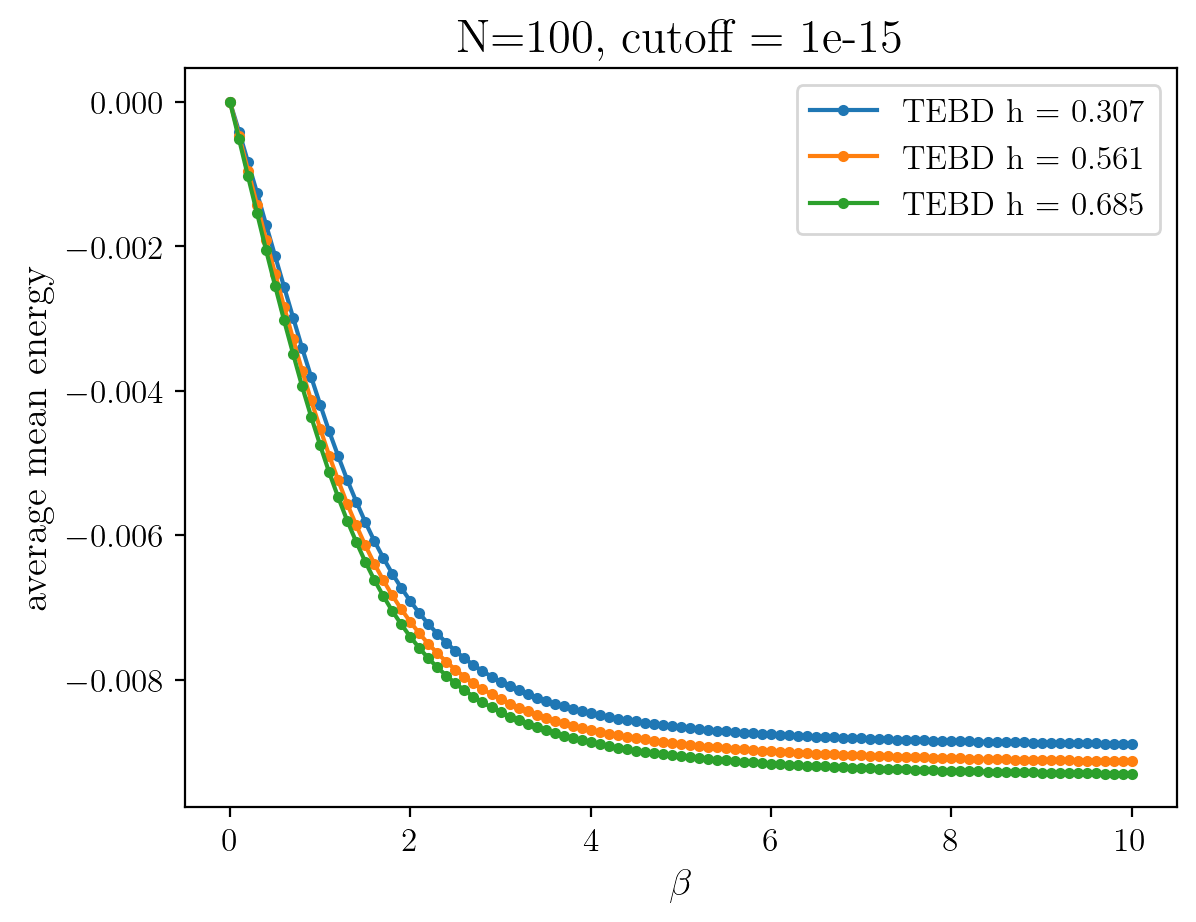

In [20]:
fig, ax = plt.subplots()
ax.plot(data_dict["h_0.307"]["beta list values"], fullmeanenergy["h_0.307"], label=f"TEBD h = {data_dict["h_0.307"]["disorder"]}", marker='.')
ax.plot(data_dict["h_0.561"]["beta list values"], fullmeanenergy["h_0.561"], label=f"TEBD h = {data_dict["h_0.561"]["disorder"]}", marker='.')
ax.plot(data_dict["h_0.685"]["beta list values"], fullmeanenergy["h_0.685"], label=f"TEBD h = {data_dict["h_0.685"]["disorder"]}", marker='.')
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("average mean energy")
ax.set_title("N={}, cutoff = 1e-15".format(data_dict["h_0.307"]["N"]))
ax.legend()
#plt.savefig("Plots_disorder/errorglobalenergydeltatau.pdf")
plt.show()

tracer l'aimantatation en fonciton des sites pour différents beta pour vérifier le code